# Proyecto Integrador de Aprendizaje Automático

El crecimiento de las plataformas de préstamos en línea ha generado grandes volúmenes de datos financieros y socioeconómicos que representan una oportunidad para aplicar técnicas de aprendizaje automático en la predicción del riesgo crediticio. Con la plataforma de Lending Club nos proporciona un extenso conjunto de información histórica sobre los préstamos emitidos entre 2007 y 2020, al igual que variables relacionadas con el perfil del que solicita, condiciones del crédito y su estado.

El presente proyecto tiene como objetivo construir un modelo de clasificación supervisada capaz de predecir si un préstamo será pagado en su totalidad o entrará en incumplimiento. Por eso, se comparan dos enfoques: scikit-learn y con PySpark. Evaluando el rendimiento de ambos como métricas de clasificación y tiempos de ejecusión, junto con la técnica LIME para interpretar los resultados.

Aquí marcamos las librerias necesarias, los contextos guardados en el equipo y las normativas a usar:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import time
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

from sklearn.model_selection import train_test_split


In [ ]:
PROJECT_NAME = "LendingClub_Default_Clasificacion"
RESULTS_DIR  = "resultados"
FIGS_DIR     = os.path.join(RESULTS_DIR, "figs")
ARTIFACTS_DIR= os.path.join(RESULTS_DIR, "artifacts")

for d in [RESULTS_DIR, FIGS_DIR, ARTIFACTS_DIR]:
    os.makedirs(d, exist_ok=True)

CSV_FILE = "accepted_2007_to_2018Q4.csv"  

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

EDA_SAMPLE_MAX = 200_000  

# Variables claves
CORE_FEATURES = [
    # Monto y términos del préstamo
    "loan_amnt", "term", "int_rate", "installment",
    # Calificación/FICO
    "grade", "sub_grade", "fico_range_low", "fico_range_high",
    # Empleo / ingresos
    "emp_length", "emp_length_num",
    "annual_inc", "verification_status",
    # Hogar / propósito / estado
    "home_ownership", "purpose", "addr_state",
    # Deuda e historial
    "dti", "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc",
    # Estado de lista / tipo de aplicación
    "initial_list_status", "application_type",
    # Target
    "loan_status"  
]

In [ ]:
from contextlib import contextmanager

@contextmanager
def timer(msg: str):
    """Context manager simple para medir tiempos."""
    t0 = time.time()
    print(f"[⏱️] {msg} ...", end="", flush=True)
    try:
        yield
    finally:
        t1 = time.time()
        print(f" hecho en {t1 - t0:.2f}s")

def memory_usage_mb(df: pd.DataFrame) -> float:
    return float(df.memory_usage(deep=True).sum()) / (1024 ** 2)

def parse_emp_length(x):
    """
    - '10+ years' -> 10
    - '< 1 year'  -> 0
    - 'n/a'       -> NaN
    - '7 years'   -> 7
    """
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    if "10+" in s: return 10
    if "< 1" in s: return 0
    if "n/a" in s: return np.nan
    import re
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else np.nan

def save_fig(path: str, dpi: int = 120, tight: bool = True):
    """Guardar la figura actual con parámetros"""
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=dpi)
    print(f"Figura guardada en: {path}")

def save_json(obj, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    print(f"JSON guardado en: {path}")

In [ ]:
import sys
from importlib.metadata import version, PackageNotFoundError

print("Python:", sys.version)

versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
}

# scikit-learn
try:
    import sklearn
    versions["scikit_learn"] = sklearn.__version__
except Exception:
    versions["scikit_learn"] = "N/A"

# pyspark
try:
    import pyspark
    versions["pyspark"] = pyspark.__version__
except Exception:
    versions["pyspark"] = "N/A"

# lime (usa importlib.metadata)
try:
    versions["lime"] = version("lime")
except PackageNotFoundError:
    versions["lime"] = "N/A"

print("== Versiones ==")
for k, v in versions.items():
    print(f"{k:>12}: {v}")

save_json(versions, os.path.join(ARTIFACTS_DIR, "versions.json"))


Python: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
== Versiones ==
      python: 3.9.23
       numpy: 1.23.5
      pandas: 2.3.1
  matplotlib: 3.9.2
     seaborn: 0.13.2
scikit_learn: 1.6.1
     pyspark: 4.0.1
        lime: 0.2.0.1
[💾] JSON guardado en: resultados\artifacts\versions.json


In [ ]:
import os, json, random, warnings, sys
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Semillas para reproducibilidad
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Rutas
DATA_DIR     = "."
CSV_FILE     = os.path.join(DATA_DIR, "accepted_2007_to_2018Q4.csv")   # ajusta si tu CSV es otro
ARTIFACTS_DIR = "resultados"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Utilidades simples
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def mem_mb(df):
    return f"{df.memory_usage(deep=True).sum()/1024/1024:,.1f} MB"

print("Python:", sys.version)
print("Seed global:", GLOBAL_SEED)
print("CSV_FILE:", CSV_FILE)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)


Python: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
Seed global: 42
CSV_FILE: .\accepted_2007_to_2018Q4.csv
ARTIFACTS_DIR: resultados


In [ ]:
assert os.path.exists(CSV_FILE), f"No se encontró el archivo: {CSV_FILE}"

print("Cargando CSV (puede tardar un poco)...")
df = pd.read_csv(CSV_FILE, low_memory=False)
print("Shape original:", df.shape)
print("Memoria (aprox):", mem_mb(df))

# Guardamos columnas originales por referencia
cols_originales = df.columns.tolist()
save_json({"columns": cols_originales}, os.path.join(ARTIFACTS_DIR, "columns_raw.json"))

# Vista rápida
display(df.head(3))


Cargando CSV (puede tardar un poco)...
Shape original: (2260701, 151)
Memoria (aprox): 6,414.7 MB


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
valid_status = {"Fully Paid", "Charged Off"}
if "loan_status" not in df.columns:
    raise RuntimeError("No existe la columna 'loan_status' en el dataset.")

df = df[df["loan_status"].isin(valid_status)].copy()

# 1 = Charged Off (default), 0 = Fully Paid
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

print("Shape tras filtrar:", df.shape)
dist = df["default"].value_counts(normalize=True).rename({0:"Fully Paid (0)", 1:"Charged Off (1)"})
print("Distribución 'default' (%):")
display((dist * 100).round(2))

display(df[["loan_status", "default"]].head(5))


Shape tras filtrar: (1345310, 152)
Distribución 'default' (%):


default
Fully Paid (0)     80.04
Charged Off (1)    19.96
Name: proportion, dtype: float64

,loan_status,default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0


In [ ]:
# Normalizaciones básicas
for pct_col in ["int_rate", "revol_util"]:
    if pct_col in df.columns:
        df[pct_col] = (
            df[pct_col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .replace({"": np.nan, "nan": np.nan})
            .astype(float)
        )

# 2) '36 meses'/'60 meses' -> 36/60 (categórico
if "term" in df.columns:
    df["term"] = (
        df["term"].astype(str).str.extract(r"(\d+)")[0]
        .astype(float)  # float para los NaN
        .astype("Int64")  
    )

# emp_length_num (años) a partir de emp_length textual 
if "emp_length_num" not in df.columns and "emp_length" in df.columns:
    def parse_emp_length(x):
        if pd.isna(x):
            return np.nan
        s = str(x).lower()
        if "10+" in s: return 10
        if "< 1" in s: return 0
        if "n/a" in s: return np.nan
        import re
        m = re.search(r"(\d+)", s)
        return int(m.group(1)) if m else np.nan
    df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)

# Coerciones numéricas suaves 
to_float_cols = [
    "loan_amnt","installment","fico_range_low","fico_range_high","annual_inc",
    "dti","delinq_2yrs","inq_last_6mths","open_acc","pub_rec","revol_bal",
    "total_acc"
]
for c in to_float_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Tipos tras normalizaciones básicas:")
display(df.dtypes.head(30))

print("Memoria (aprox) post-norm:", mem_mb(df))


Tipos tras normalizaciones básicas:


id                      object
member_id              float64
loan_amnt              float64
funded_amnt            float64
funded_amnt_inv        float64
term                     Int64
int_rate               float64
installment            float64
grade                   object
sub_grade               object
emp_title               object
emp_length              object
home_ownership          object
annual_inc             float64
verification_status     object
issue_d                 object
loan_status             object
pymnt_plan              object
url                     object
desc                    object
purpose                 object
title                   object
zip_code                object
addr_state              object
dti                    float64
delinq_2yrs            float64
earliest_cr_line        object
fico_range_low         float64
fico_range_high        float64
inq_last_6mths         float64
dtype: object

Memoria (aprox) post-norm: 3,762.6 MB


In [ ]:
# Varibles de interés
candidate_features = [
    # Monto y términos del préstamo
    "loan_amnt", "term", "int_rate", "installment",
    # Calificación crediticia y FICO al orig.
    "grade", "sub_grade", "fico_range_low", "fico_range_high",
    # Empleo e ingresos
    "emp_length", "emp_length_num",
    "annual_inc", "verification_status",
    # Hogar y propósito
    "home_ownership", "purpose", "addr_state",
    # Deuda, historial y cuentas
    "dti", "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc",
    # Estado inicial de la lista y tipo de aplicación
    "initial_list_status", "application_type",
    # Target
    "default"
]

cols_present = [c for c in candidate_features if c in df.columns]
missing_cols = sorted(set(candidate_features) - set(cols_present))
if missing_cols:
    print("Advertencia: no se encontraron algunas columnas esperadas:", missing_cols)

df = df[cols_present].copy()
print("Columnas seleccionadas:", len(df.columns))
display(df.head(3))
print("Memoria (aprox) subset:", mem_mb(df))


Columnas seleccionadas: 26


,loan_amnt,term,int_rate,installment,grade,sub_grade,fico_range_low,fico_range_high,emp_length,emp_length_num,...,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,default
0,3600.0,36,13.99,123.03,C,C4,675.0,679.0,10+ years,10.0,...,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,Individual,0
1,24700.0,36,11.99,820.28,C,C1,715.0,719.0,10+ years,10.0,...,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,Individual,0
2,20000.0,60,10.78,432.66,B,B4,695.0,699.0,10+ years,10.0,...,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,w,Joint App,0


Memoria (aprox) subset: 909.0 MB


In [ ]:
# Guardamos a Parquet
PARQUET_PATH = os.path.join(ARTIFACTS_DIR, "lendingclub_filtered.parquet")
CSV_FILTERED = os.path.join(ARTIFACTS_DIR, "lendingclub_filtered.csv")

try:
    df.to_parquet(PARQUET_PATH, index=False)
    print("Guardado (parquet):", PARQUET_PATH)
except Exception as e:
    print("No se pudo guardar como parquet:", e)

# Guardamos también como CSV ligero (útil para revisar fuera de Python)
try:
    df.head(500_000).to_csv(CSV_FILTERED, index=False)  # head para no generar un CSV gigante accidentalmente
    print("Guardado (CSV muestra):", CSV_FILTERED)
except Exception as e:
    print("No se pudo guardar CSV filtrado:", e)


No se pudo guardar como parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
Guardado (CSV muestra): resultados\lendingclub_filtered.csv


In [ ]:
# Resumen del dataset
print("Shape actual:", df.shape)
print("Memoria (aprox):", mem_mb(df))

print("\n--- Primeras filas ---")
display(df.head(5))

print("\n--- Info rápida ---")
print(df.info())

print("\n--- Resumen estadístico (numéricas) ---")
display(df.describe().T)

print("\n--- Resumen estadístico (categóricas) ---")
cat_cols = [c for c in df.columns if df[c].dtype == "object" and c != "loan_status"]
for c in cat_cols[:10]:
    print(f"\nColumna: {c}")
    print(df[c].value_counts(dropna=False).head(10))


Shape actual: (1345310, 26)
Memoria (aprox): 909.0 MB

--- Primeras filas ---


,loan_amnt,term,int_rate,installment,grade,sub_grade,fico_range_low,fico_range_high,emp_length,emp_length_num,...,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,default
0,3600.0,36,13.99,123.03,C,C4,675.0,679.0,10+ years,10.0,...,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,Individual,0
1,24700.0,36,11.99,820.28,C,C1,715.0,719.0,10+ years,10.0,...,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,Individual,0
2,20000.0,60,10.78,432.66,B,B4,695.0,699.0,10+ years,10.0,...,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,w,Joint App,0
4,10400.0,60,22.45,289.91,F,F1,695.0,699.0,3 years,3.0,...,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,Individual,0
5,11950.0,36,13.44,405.18,C,C3,690.0,694.0,4 years,4.0,...,0.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,Individual,0



--- Info rápida ---
<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1345310 non-null  float64
 1   term                 1345310 non-null  Int64  
 2   int_rate             1345310 non-null  float64
 3   installment          1345310 non-null  float64
 4   grade                1345310 non-null  object 
 5   sub_grade            1345310 non-null  object 
 6   fico_range_low       1345310 non-null  float64
 7   fico_range_high      1345310 non-null  float64
 8   emp_length           1266799 non-null  object 
 9   emp_length_num       1266799 non-null  float64
 10  annual_inc           1345310 non-null  float64
 11  verification_status  1345310 non-null  object 
 12  home_ownership       1345310 non-null  object 
 13  purpose              1345310 non-null  object 
 14  addr_state           1345310 non-n

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1345310.0,14419.972014,8717.050787,500.0,8000.0,12000.0,20000.0,40000.0
term,1345310.0,41.790196,10.268321,36.0,36.0,36.0,36.0,60.0
int_rate,1345310.0,13.239619,4.768716,5.31,9.75,12.74,15.99,30.99
installment,1345310.0,438.075533,261.512604,4.93,248.48,375.43,580.73,1719.83
fico_range_low,1345310.0,696.185039,31.852512,625.0,670.0,690.0,710.0,845.0
fico_range_high,1345310.0,700.185177,31.853161,629.0,674.0,694.0,714.0,850.0
emp_length_num,1266799.0,5.965873,3.691166,0.0,2.0,6.0,10.0,10.0
annual_inc,1345310.0,76247.636414,69925.098427,0.0,45780.0,65000.0,90000.0,10999200.0
dti,1344936.0,18.282667,11.160446,-1.0,11.79,17.61,24.06,999.0
delinq_2yrs,1345310.0,0.317794,0.877992,0.0,0.0,0.0,0.0,39.0



--- Resumen estadístico (categóricas) ---

Columna: grade
grade
B    392741
C    381686
A    235090
D    200953
E     93650
F     32058
G      9132
Name: count, dtype: int64

Columna: sub_grade
sub_grade
C1    85494
B4    83199
B5    82538
B3    81827
C2    79213
C3    74998
C4    74421
B2    74024
B1    71153
C5    67560
Name: count, dtype: int64

Columna: emp_length
emp_length
10+ years    442199
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
NaN           78511
6 years       62733
8 years       60701
Name: count, dtype: int64

Columna: verification_status
verification_status
Source Verified    521273
Verified           418336
Not Verified       405701
Name: count, dtype: int64

Columna: home_ownership
home_ownership
MORTGAGE    665579
RENT        534421
OWN         144832
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64

Columna: purpose
purpose
debt_consolidation    780321
cr

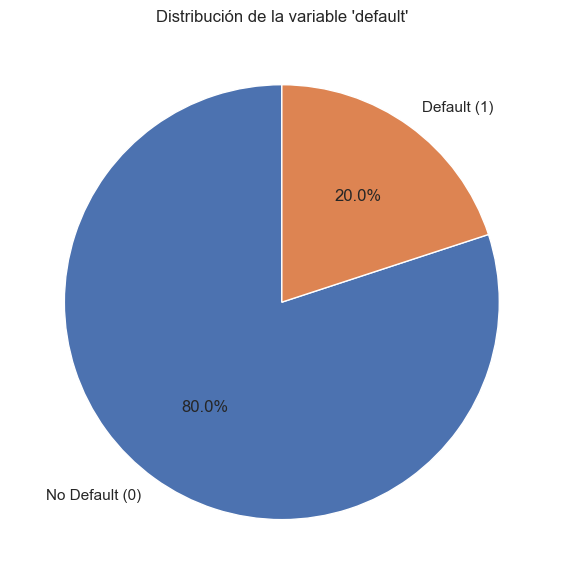

Distribución absoluta de default:
 default
0    1076751
1     268559
Name: count, dtype: int64


In [ ]:
# Distribución del target
counts = df["default"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["No Default (0)", "Default (1)"], autopct="%1.1f%%", startangle=90)
plt.title("Distribución de la variable 'default'")
plt.tight_layout()
plt.show()
print("Distribución absoluta de default:\n", df["default"].value_counts())

Revisamos los faltantes del dataset

In [ ]:
na_tbl = (
    df.isna().mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
    .assign(missing_pct=lambda x: (x["missing_rate"]*100).round(2))
)

print("\n--- Porcentaje de NA (top 20) ---")
display(na_tbl.head(20))

print("\n--- Cardinalidad (número de valores únicos) ---")
cardinality = df.nunique(dropna=False).sort_values(ascending=False)
display(cardinality.head(20))



--- Porcentaje de NA (top 20) ---


,missing_rate,missing_pct
emp_length,5.835904e-02,5.84
emp_length_num,5.835904e-02,5.84
revol_util,6.370279e-04,0.06
dti,2.780028e-04,0.03
inq_last_6mths,7.433231e-07,0.00
loan_amnt,0.000000e+00,0.00
addr_state,0.000000e+00,0.00
application_type,0.000000e+00,0.00
initial_list_status,0.000000e+00,0.00
total_acc,0.000000e+00,0.00



--- Cardinalidad (número de valores únicos) ---


revol_bal          83810
installment        83307
annual_inc         64362
dti                 7068
loan_amnt           1556
revol_util          1374
int_rate             654
total_acc            142
open_acc              84
addr_state            51
fico_range_low        40
fico_range_high       40
pub_rec               37
sub_grade             35
delinq_2yrs           31
purpose               14
emp_length_num        12
emp_length            12
inq_last_6mths        10
grade                  7
dtype: int64

Visualizamos las variables numéricas:

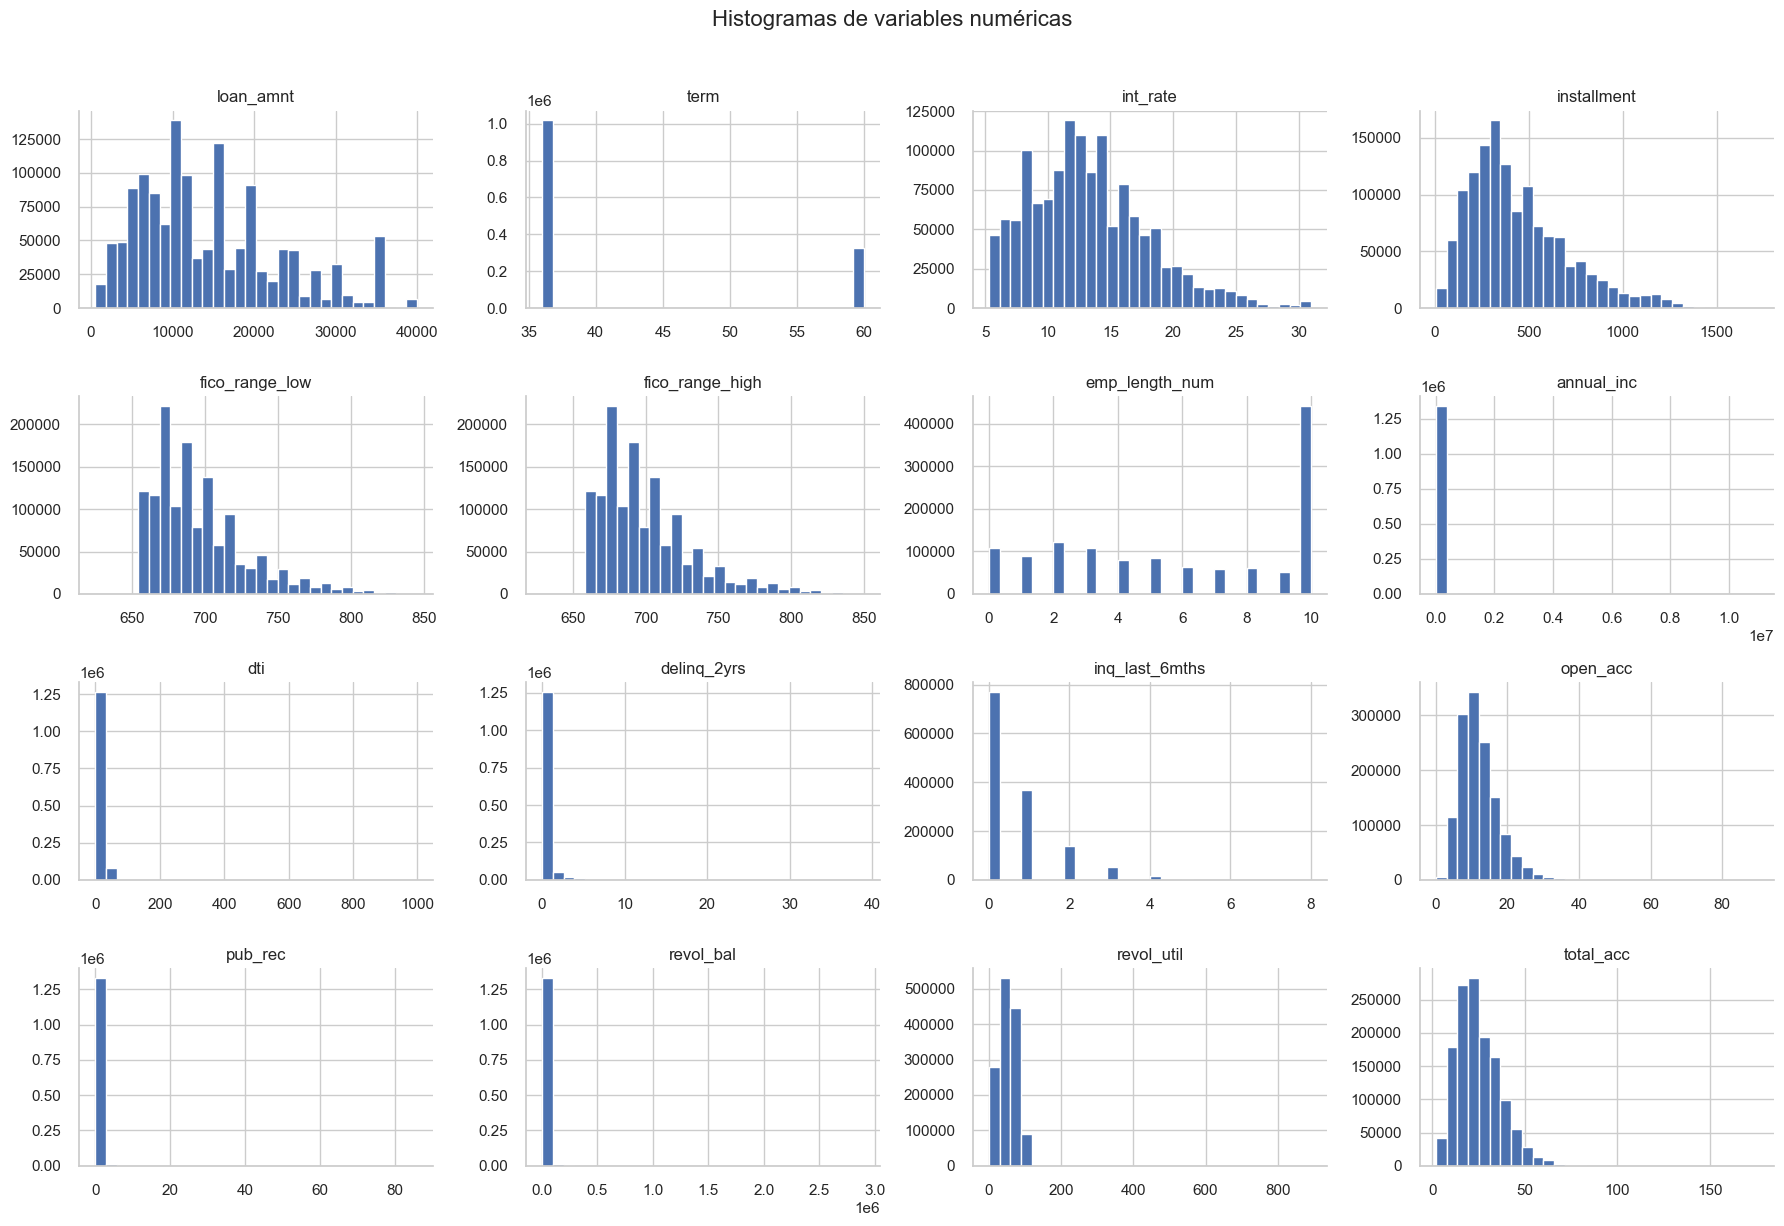

In [ ]:
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "default"]

if num_cols:
    df[num_cols].hist(bins=30, figsize=(18, 12))
    plt.suptitle("Histogramas de variables numéricas", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron columnas numéricas para graficar.")

Vemos los boxplots de las variables numericas claves para el estudio

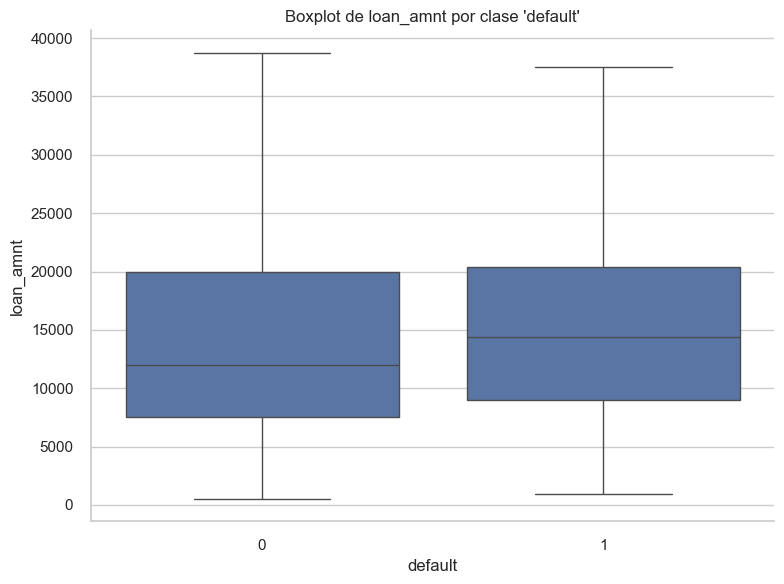

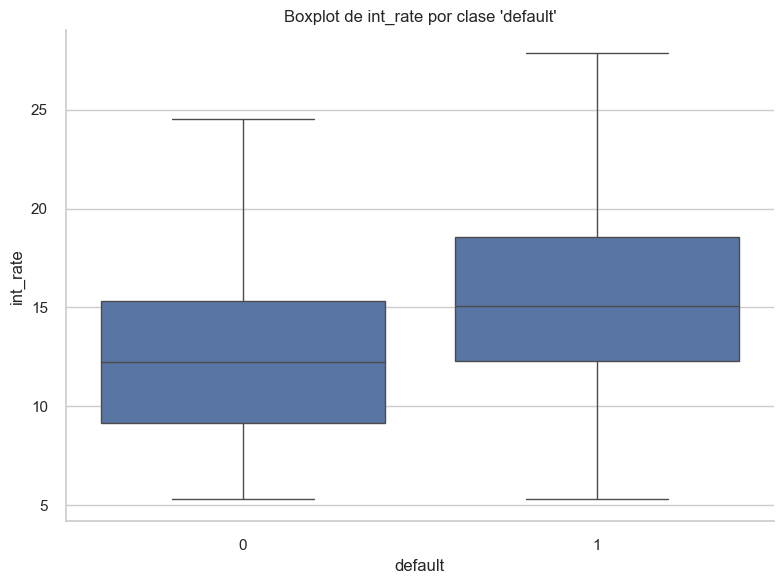

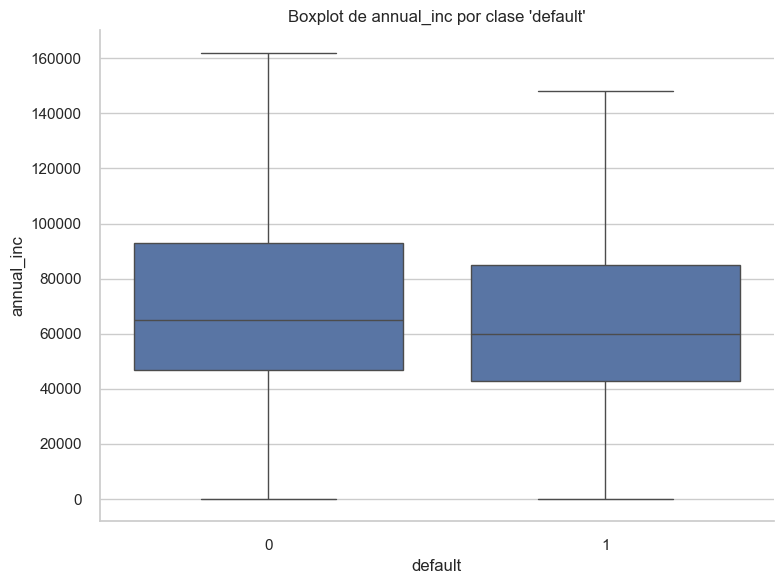

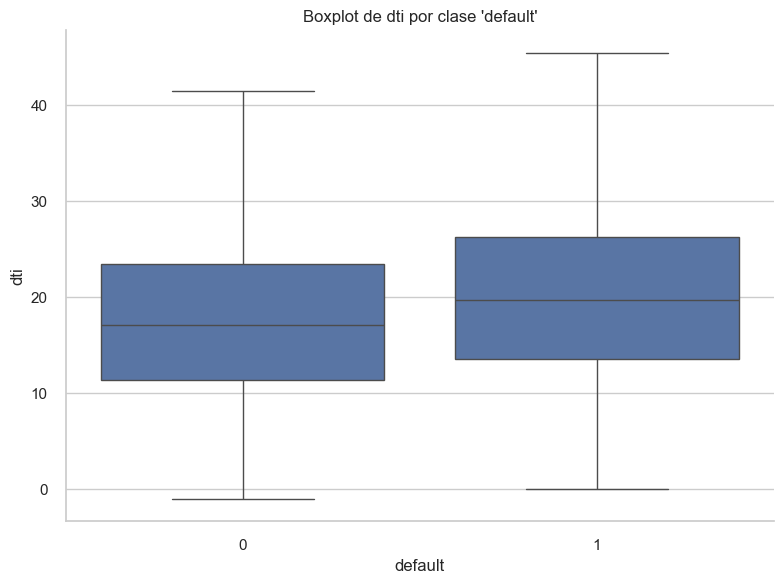

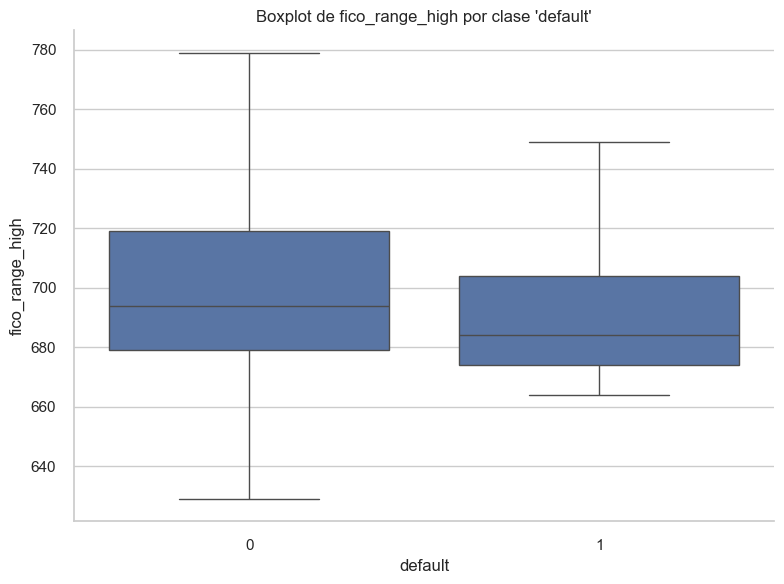

In [ ]:
box_cols = [c for c in ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high"] if c in num_cols]

for c in box_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x="default", y=c, data=df, showfliers=False)
    plt.title(f"Boxplot de {c} por clase 'default'")
    plt.tight_layout()
    plt.show()


Vemos entre cuales variables existen correlaciones:

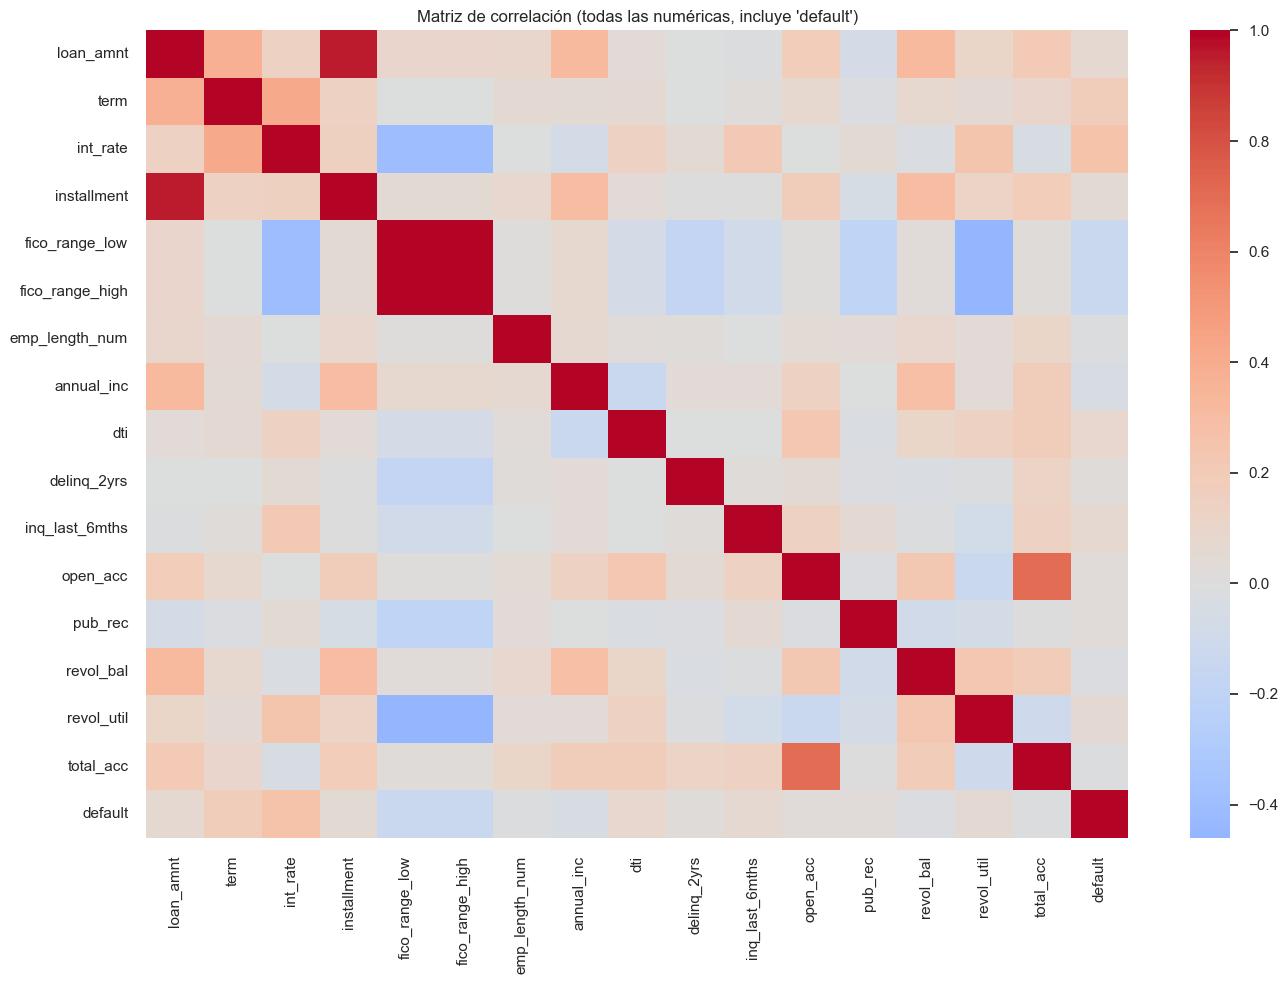


--- Correlaciones con 'default' (numéricas) ---


default            1.000000
int_rate           0.258792
term               0.176096
dti                0.084510
loan_amnt          0.065604
inq_last_6mths     0.065454
revol_util         0.060048
installment        0.051701
open_acc           0.028078
pub_rec            0.026194
delinq_2yrs        0.019381
total_acc         -0.011300
emp_length_num    -0.014235
revol_bal         -0.020010
annual_inc        -0.041759
fico_range_high   -0.130682
fico_range_low    -0.130683
dtype: float64

In [ ]:
# 'default' sea numérica (0 o 1)
if "default" in df.columns:
    df["default"] = pd.to_numeric(df["default"], errors="coerce")

num_cols_all = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

if len(num_cols_all) >= 2:
    corr = df[num_cols_all].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación (todas las numéricas, incluye 'default')")
    plt.tight_layout()
    plt.show()

    if "default" in corr.columns:
        print("\n--- Correlaciones con 'default' (numéricas) ---")
        corr_with_default = df[num_cols_all].corrwith(df["default"]).dropna().sort_values(ascending=False)
        display(corr_with_default)
    else:
        print("Nota: 'default' no está en el set numérico para correlaciones.")
else:
    print("No hay suficientes columnas numéricas para calcular una matriz de correlación.")



Aplicamos un Target Leakage scan para algunas variables categóricas en este estudio:

In [ ]:
from sklearn.metrics import mutual_info_score
leak_scores = {}
for c in cat_cols:
    try:
        score = mutual_info_score(df[c].astype(str), df["default"])
        leak_scores[c] = score
    except Exception:
        continue

if leak_scores:
    leak_sorted = pd.Series(leak_scores).sort_values(ascending=False)
    print("\nPosibles variables con alta info respecto a 'default':")
    display(leak_sorted.head(15))
else:
    print("No se calcularon mutual infos (sin categóricas).")



Posibles variables con alta info respecto a 'default':


sub_grade              0.036814
grade                  0.034829
verification_status    0.004370
home_ownership         0.002501
purpose                0.001543
addr_state             0.001294
emp_length             0.000991
application_type       0.000124
initial_list_status    0.000027
dtype: float64

Ya revisado todo esto

Ahora iniciamos con las pruebas para el uso de técnicas propuestas para este proyecto

In [ ]:
# SPLIT TRAIN/TEST
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default"])
y = df["default"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=GLOBAL_SEED,
    stratify=y
)

print("Shapes -> Train:", X_train.shape, "| Test:", X_test.shape)
print("Distribución train:", y_train.value_counts(normalize=True).to_dict())
print("Distribución test:", y_test.value_counts(normalize=True).to_dict())


Shapes -> Train: (1076248, 25) | Test: (269062, 25)
Distribución train: {0: 0.8003740773502018, 1: 0.1996259226497982}
Distribución test: {0: 0.8003731481963265, 1: 0.1996268518036735}


Hacemos una detección de los tipos y el perfil de los datos faltantes por la base:

In [ ]:
# DETECCIÓN DE TIPOS Y PERFIL DE NULOS POR SPLIT
cat_features = [c for c in X_train.columns if X_train[c].dtype == "object"]
num_features = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]

print("Numéricas:", len(num_features), "| Categóricas:", len(cat_features))

print("\n--- % NA en train (top 10) ---")
display(X_train[num_features+cat_features].isna().mean().sort_values(ascending=False).head(10))


Numéricas: 16 | Categóricas: 9

--- % NA en train (top 10) ---


emp_length_num         5.837502e-02
emp_length             5.837502e-02
revol_util             6.457619e-04
dti                    2.750295e-04
inq_last_6mths         9.291539e-07
loan_amnt              0.000000e+00
initial_list_status    0.000000e+00
addr_state             0.000000e+00
purpose                0.000000e+00
home_ownership         0.000000e+00
dtype: float64

Al ver presencia de estos faltantes, aplicamos imputación a estas variables de tipo uméricas encontradas usando la mediana, y para las categóricas aplicamos una nueva categoría: 

In [ ]:
from sklearn.impute import SimpleImputer

# Numéricas 
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_features]),
    columns=num_features, index=X_train.index
)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_features]),
    columns=num_features, index=X_test.index
)

# Categóricas
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_features]),
    columns=cat_features, index=X_train.index
)
X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[cat_features]),
    columns=cat_features, index=X_test.index
)


Para el tratamientos de atípicos usamos Clipping en el conjunto de entrenamiento (1-99%)

In [ ]:
clip_bounds = {}
for c in num_features:
    lo, hi = X_train_num[c].quantile([0.01, 0.99]).values
    clip_bounds[c] = (lo, hi)
    X_train_num[c] = X_train_num[c].clip(lo, hi)
    X_test_num[c]  = X_test_num[c].clip(lo, hi)

print("Ejemplo bounds (5 vars):", dict(list(clip_bounds.items())[:5]))


Ejemplo bounds (5 vars): {'loan_amnt': (1500.0, 35000.0), 'term': (36.0, 60.0), 'int_rate': (5.32, 26.3), 'installment': (52.96469999999999, 1222.4213000000059), 'fico_range_low': (660.0, 800.0)}


Hacemos un escalado para las variable numéricas:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num).astype(np.float32),
    columns=num_features, index=X_train.index
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num).astype(np.float32),
    columns=num_features, index=X_test.index
)

Agrupamos algunos razgos dudosos de la base:

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix, hstack

if cat_features:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=0.01)
    X_train_cat_ohe = ohe.fit_transform(X_train_cat)
    X_test_cat_ohe  = ohe.transform(X_test_cat)
    ohe_cols = ohe.get_feature_names_out(cat_features)
else:
    from scipy.sparse import csr_matrix
    X_train_cat_ohe = csr_matrix((len(X_train), 0), dtype=np.float32)
    X_test_cat_ohe  = csr_matrix((len(X_test), 0), dtype=np.float32)
    ohe_cols = []


Con estas pruebas vemos las nuevas dimensiones del conjunto de entrenamiento y el de prueba:

In [ ]:
X_train_num_csr = csr_matrix(X_train_num_scaled.values.astype(np.float32))
X_test_num_csr  = csr_matrix(X_test_num_scaled.values.astype(np.float32))

X_train_processed = hstack([X_train_num_csr, X_train_cat_ohe], dtype=np.float32).tocsr()
X_test_processed  = hstack([X_test_num_csr,  X_test_cat_ohe],  dtype=np.float32).tocsr()

feature_names = list(num_features) + list(ohe_cols)

print("Shape final X_train:", X_train_processed.shape)
print("Shape final X_test:", X_test_processed.shape)

Shape final X_train: (1076248, 110)
Shape final X_test: (269062, 110)


Hacemos un balanceo de las clases para ver su impotancia en términos ponderados:

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Pesos de clase:", class_weight_dict)


Pesos de clase: {0: 0.6247078886604497, 1: 2.504684729132825}


Ahora, aplicamos Gridsearch:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedShuffleSplit
import time, gc

SUBSAMPLE_FOR_GRID = 200_000   # número de filas para GridSearch 
MAX_SAMPLES = 0.70             # fracción de filas por árbol 
N_SPLITS_CV = 3                

n_samples = X_train_processed.shape[0]
if n_samples > SUBSAMPLE_FOR_GRID:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSAMPLE_FOR_GRID, random_state=GLOBAL_SEED)
    sub_idx, _ = next(sss.split(np.zeros(n_samples), y_train.values))
    Xg = X_train_processed[sub_idx]
    yg = y_train.values[sub_idx].astype(np.int8)
else:
    Xg = X_train_processed
    yg = y_train.values.astype(np.int8)

print(f"GridSearch con {Xg.shape[0]:,} filas (de {n_samples:,}). MAX_SAMPLES={MAX_SAMPLES}")

GridSearch con 200,000 filas (de 1,076,248). MAX_SAMPLES=0.7


Hacemos el modelo base con los hiperparámetros:

In [ ]:
rf_base = RandomForestClassifier(
    random_state=GLOBAL_SEED,
    n_jobs=-1,
    class_weight=class_weight_dict,
    bootstrap=True,
    max_samples=MAX_SAMPLES
)

param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15]
}
cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=GLOBAL_SEED)
print("Parámetros a evaluar:", param_grid)

Parámetros a evaluar: {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 15]}


In [ ]:
# Subconjunto de Gridsearch
from sklearn.metrics import roc_auc_score

print("Buscando hiperparámetros (sklearn) en subconjunto...")
sk_grid_start = time.time()

gs = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,          
    verbose=1,
    pre_dispatch=1
)

gs.fit(Xg, yg)
sk_grid_end = time.time()
sk_grid_time = sk_grid_end - sk_grid_start

best_params = gs.best_params_
print("Mejores parámetros (subset):", best_params)
print(f"Mejor ROC AUC CV (subset): {gs.best_score_:.4f}")
print(f"Tiempo Grid (subset): {sk_grid_time:.2f} s")


Buscando hiperparámetros (sklearn) en subconjunto...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejores parámetros (subset): {'max_depth': 10, 'n_estimators': 100}
Mejor ROC AUC CV (subset): 0.7091
Tiempo Grid (subset): 238.76 s


Aquí entrenamos el modelo final:

In [ ]:
best_rf = RandomForestClassifier(
    random_state=GLOBAL_SEED,
    n_jobs=-1,
    class_weight=class_weight_dict,
    bootstrap=True,
    max_samples=MAX_SAMPLES,
    **best_params
)

print("\nEntrenando modelo final en TODO el train...")
sk_fit_start = time.time()
best_rf.fit(X_train_processed, y_train.values.astype(np.int8))
sk_fit_end = time.time()
sk_fit_time = sk_fit_end - sk_fit_start

print(f"Tiempo entrenamiento final (full train): {sk_fit_time:.2f} s")



Entrenando modelo final en TODO el train...
Tiempo entrenamiento final (full train): 266.40 s


Predecimos las métricas del modelo:

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

pred_start = time.time()
y_pred = best_rf.predict(X_test_processed)
y_pred_proba = best_rf.predict_proba(X_test_processed)[:, 1]
pred_end = time.time()
sk_pred_time = pred_end - pred_start

sk_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_pred_proba),
    "Train Time (s)": sk_grid_time + sk_fit_time,
    "Pred Time (s)": sk_pred_time
}

print("\nMétricas (sklearn, final):")
for k, v in sk_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


Métricas (sklearn, final):
Accuracy: 0.6197
Precision: 0.3035
Recall: 0.6987
F1-Score: 0.4232
ROC AUC: 0.7085
Train Time (s): 505.1597
Pred Time (s): 1.5896


Hacemos las visualizaciones:

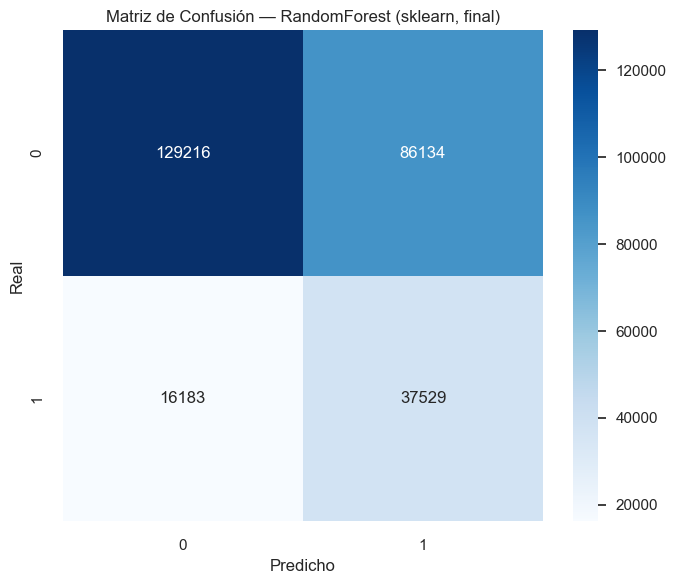

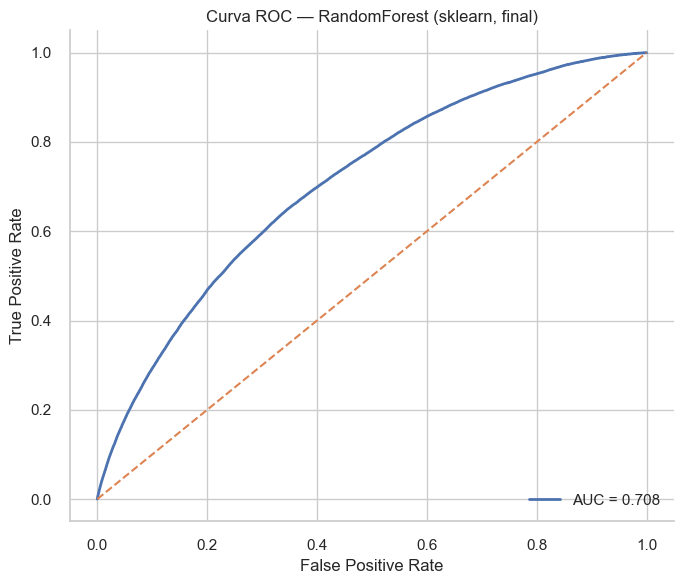

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión — RandomForest (sklearn, final)")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_skl = auc(fpr, tpr)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_skl:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC — RandomForest (sklearn, final)")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()


Buscamos y visualizamos las variables más importantes:

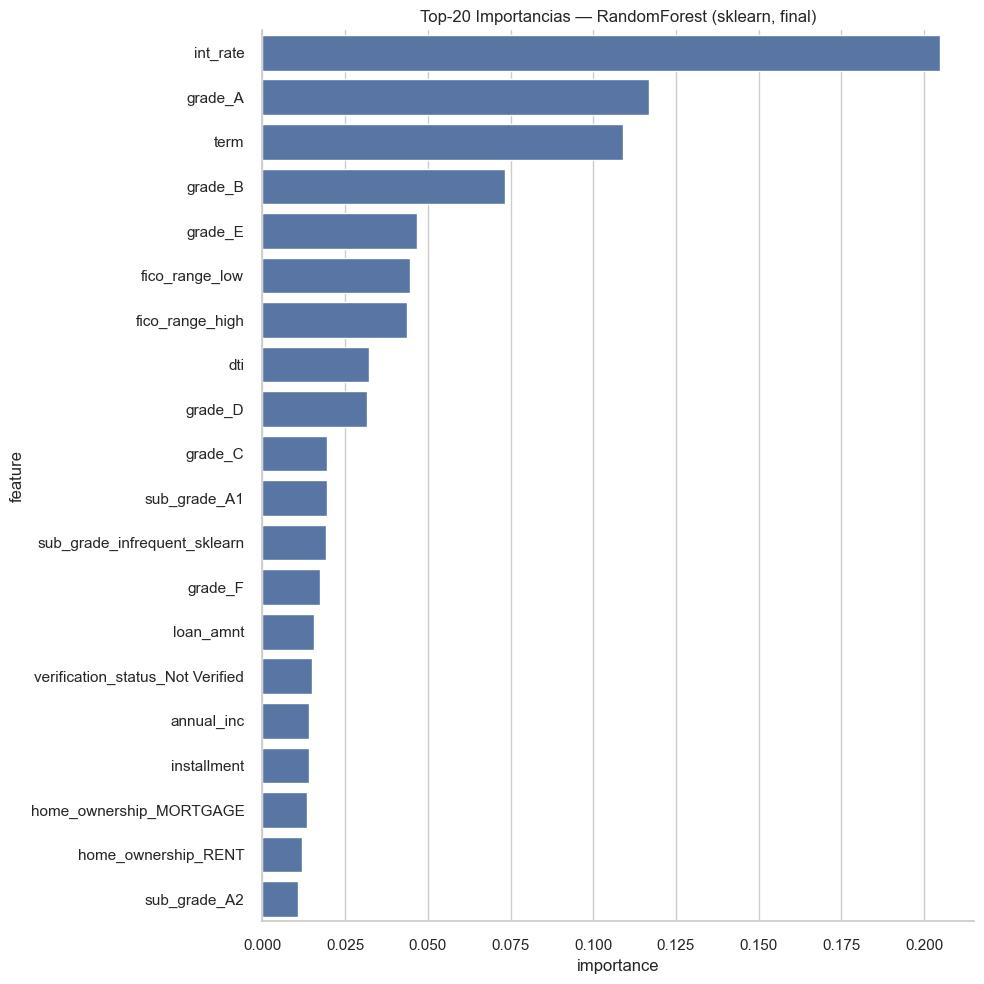

Guardado: resultados\importancias_sklearn_rf.csv


In [ ]:
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(data=fi.head(20), x="importance", y="feature")
plt.title("Top-20 Importancias — RandomForest (sklearn, final)")
plt.tight_layout(); plt.show()

fi_path = os.path.join(ARTIFACTS_DIR, "importancias_sklearn_rf.csv")
fi.to_csv(fi_path, index=False)
print("Guardado:", fi_path)

Usando técnicas de Java

In [ ]:
JDK_HOME = r"C:\Program Files\Java\jdk-21"

import os, shutil, subprocess, sys
os.environ["JAVA_HOME"] = JDK_HOME
os.environ["PATH"] = JDK_HOME + r"\bin;" + os.environ["PATH"]

print("Python:", sys.version)
print("sys.executable:", sys.executable)
print("JAVA_HOME (uso actual del proceso):", os.environ.get("JAVA_HOME"))
print("java encontrado en PATH:", shutil.which("java"))

# 2) Verifica que el java activo es el del JDK 21
subprocess.run(["where", "java"], check=False)
subprocess.run(["java", "-version"], check=False)

Python: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
sys.executable: c:\Users\potot\miniconda3\envs\ml_venv\python.exe
JAVA_HOME (uso actual del proceso): C:\Program Files\Java\jdk-21
java encontrado en PATH: C:\Program Files\Java\jdk-21\bin\java.EXE


CompletedProcess(args=['java', '-version'], returncode=0)

In [ ]:
from pyspark.sql import SparkSession

CORES = None            
DRIVER_MEM_GB = 12      
SHUFFLE_PARTS = 12
GLOBAL_SEED = 42

master = f"local[{CORES}]" if isinstance(CORES, int) and CORES > 0 else "local[*]"

spark = (
    SparkSession.builder
    .master(master)
    .appName("LendingClub_RF_Spark")
    # estabilidad local/Windows/puertos
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.port.maxRetries", "64")
    .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true")
    .config("spark.executor.extraJavaOptions", "-Djava.net.preferIPv4Stack=true")
    .config("spark.ui.enabled", "false")
    # memoria/ejecución
    .config("spark.driver.memory", f"{DRIVER_MEM_GB}g")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTS))
    .config("spark.default.parallelism", str(SHUFFLE_PARTS))
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

import pyspark
print("Spark version:", spark.version, "| PySpark:", pyspark.__version__)
print("JAVA_HOME que ve Spark:", os.environ.get("JAVA_HOME"))


Spark version: 4.0.1 | PySpark: 4.0.1
JAVA_HOME que ve Spark: C:\Program Files\Java\jdk-21


In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, StringType

# creamos spark_df
df_pd = pd.concat([X, y.rename("default")], axis=1)

# Detección de tipos desde pandas
pd_num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
pd_cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]

# Limpieza
drop_cols = []
for c in pd_num_cols:
    if X[c].notna().sum() == 0:   
        drop_cols.append(c)
for c in pd_cat_cols:
    s = X[c].dropna()
    if s.nunique() < 2:           
        drop_cols.append(c)

if drop_cols:
    df_pd = df_pd.drop(columns=drop_cols, errors="ignore")
    pd_num_cols = [c for c in pd_num_cols if c not in drop_cols]
    pd_cat_cols = [c for c in pd_cat_cols if c not in drop_cols]

spark_df = spark.createDataFrame(df_pd)

for c in pd_num_cols:
    spark_df = spark_df.withColumn(c, col(c).cast(DoubleType()))
for c in pd_cat_cols:
    spark_df = spark_df.withColumn(c, col(c).cast(StringType()))
spark_df = spark_df.withColumn("default", col("default").cast(DoubleType()))

spark_df.printSchema()
print("Filas totales:", spark_df.count())


root
 |-- loan_amnt: double (nullable = true)
 |-- term: double (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- emp_length_num: double (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- inq_last_6mths: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: double (nullable = true)
 |-- total_acc: double (nullable = true)
 |-- initial_list_status: str

In [ ]:
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer

stages = []

# Imputación numérica
numeric_final = []
if pd_num_cols:
    imputer = Imputer(
        inputCols=pd_num_cols,
        outputCols=[c + "_imp" for c in pd_num_cols],
        strategy="mean"
    )
    stages.append(imputer)
    numeric_final = [c + "_imp" for c in pd_num_cols]

# Indexado de variable scategóricas 
indexed_cats = []
for c in pd_cat_cols:
    stages.append(StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep"))
    indexed_cats.append(c + "_idx")

# 3) Ensamble de features directo (sin VectorIndexer)
assembler_inputs = numeric_final + indexed_cats
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="keep")
stages.append(assembler)

print("Stages del pipeline:", [type(s).__name__ for s in stages])


Stages del pipeline: ['Imputer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'StringIndexer', 'VectorAssembler']


In [ ]:
from pyspark.sql.functions import when, col
from pyspark import StorageLevel

# Split 80/20 
train_sp, test_sp = spark_df.randomSplit([0.8, 0.2], seed=GLOBAL_SEED)

# Pesos de clase 
cls_counts = {row["default"]: row["count"] for row in train_sp.groupBy("default").count().collect()}
pos = cls_counts.get(1.0, cls_counts.get(1, 1))
neg = cls_counts.get(0.0, cls_counts.get(0, 1))
pos_weight = float(neg) / float(pos) if pos else 1.0

train_sp = train_sp.withColumn("class_weight", when(col("default") == 1.0, pos_weight).otherwise(1.0))
test_sp  = test_sp.withColumn("class_weight",  when(col("default") == 1.0, pos_weight).otherwise(1.0))

train_sp = train_sp.persist(StorageLevel.DISK_ONLY)
test_sp  = test_sp.persist(StorageLevel.DISK_ONLY)
_ = train_sp.limit(1).collect(); _ = test_sp.limit(1).collect()

print("Recuento train por clase:", cls_counts, "| pos_weight:", round(pos_weight, 3))
print("train/test:", train_sp.count(), test_sp.count())

GRID_SAMPLE_FRAC = 0.25
GRID_SAMPLE_FRAC = max(0.05, min(0.9, GRID_SAMPLE_FRAC))
train_cv = train_sp.sample(False, GRID_SAMPLE_FRAC, seed=GLOBAL_SEED).persist(StorageLevel.DISK_ONLY)
if train_cv.limit(1).count() == 0:
    train_cv = train_sp.sample(False, 0.5, seed=7).persist(StorageLevel.DISK_ONLY)

print("Filas train para CV:", train_cv.count(), f"(frac={GRID_SAMPLE_FRAC})")


Recuento train por clase: {0.0: 861731, 1.0: 214961} | pos_weight: 4.009
train/test: 1076692 268618
Filas train para CV: 269405 (frac=0.25)


In [ ]:
import time
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

rf = SparkRF(
    featuresCol="features",
    labelCol="default",
    weightCol="class_weight",
    seed=GLOBAL_SEED,
    maxBins=512,                    
    featureSubsetStrategy="sqrt",
    subsamplingRate=0.7
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 50, 100])
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

pipeline = SparkPipeline(stages=stages + [rf])

CV_FOLDS = 3
import os
CV_PARALLELISM = max(2, (os.cpu_count() or 4) // 2)

print("CV en subset...")
sp_cv_start = time.time()
cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=CV_FOLDS,
    parallelism=CV_PARALLELISM,
    seed=GLOBAL_SEED
)
cv_model = cv.fit(train_cv)
sp_cv_time = time.time() - sp_cv_start
print(f"Tiempo CV subset: {sp_cv_time:.2f}s")

best_pipeline = cv_model.bestModel
best_rf = best_pipeline.stages[-1]
best_params = {"numTrees": best_rf.getOrDefault("numTrees"), "maxDepth": best_rf.getOrDefault("maxDepth")}
print("Mejores hiperparámetros (CV subset):", best_params)


CV en subset...
Tiempo CV subset: 2146.78s
Mejores hiperparámetros (CV subset): {'numTrees': 100, 'maxDepth': 10}


In [45]:
rf_best = SparkRF(
    featuresCol="features",
    labelCol="default",
    weightCol="class_weight",
    seed=GLOBAL_SEED,
    maxBins=512,
    featureSubsetStrategy="sqrt",
    subsamplingRate=0.7,
    numTrees=best_params["numTrees"],
    maxDepth=best_params["maxDepth"]
)
full_pipeline = SparkPipeline(stages=stages + [rf_best])

print("Refit en TODO el train con mejores hiperparámetros...")
sp_fit_start = time.time()
best_model = full_pipeline.fit(train_sp)
sp_fit_time = time.time() - sp_fit_start
sp_train_time = sp_cv_time + sp_fit_time
print(f"Tiempo total entrenamiento (CV subset + refit full): {sp_train_time:.2f}s")


Refit en TODO el train con mejores hiperparámetros...
Tiempo total entrenamiento (CV subset + refit full): 2472.37s


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

sp_pred_start = time.time()
preds_best = best_model.transform(test_sp).select("default", "prediction", "rawPrediction", "probability")
sp_pred_time = time.time() - sp_pred_start

# AUC (Spark)
pyspark_auc = evaluator.evaluate(preds_best)

# Métricas multiclase
mce = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction")
acc_eval = mce.setMetricName("accuracy").evaluate(preds_best)
f1_eval  = mce.setMetricName("f1").evaluate(preds_best)
prec_eval = mce.setMetricName("weightedPrecision").evaluate(preds_best)
rec_eval  = mce.setMetricName("weightedRecall").evaluate(preds_best)

# Matriz de confusión 
cm_rows = preds_best.groupBy("default", "prediction").count().collect()
cm_dict = {(float(r["default"]), float(r["prediction"])): r["count"] for r in cm_rows}
tn = cm_dict.get((0.0, 0.0), 0); fp = cm_dict.get((0.0, 1.0), 0)
fn = cm_dict.get((1.0, 0.0), 0); tp = cm_dict.get((1.0, 1.0), 0)

pyspark_metrics = {
    "Accuracy": acc_eval,
    "Precision": prec_eval,
    "Recall": rec_eval,
    "F1-Score": f1_eval,
    "ROC AUC": pyspark_auc,
    "Train Time (s)": sp_train_time,
    "Pred Time (s)": sp_pred_time,
    "ConfusionMatrix": [[tn, fp], [fn, tp]],
    "BestParams": best_params
}

print("\nMÉTRICAS (PySpark):")
for k, v in pyspark_metrics.items():
    if k in ("ConfusionMatrix", "BestParams"): continue
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print("  BestParams:", pyspark_metrics["BestParams"])
print("  ConfusionMatrix [[TN,FP],[FN,TP]]:", pyspark_metrics["ConfusionMatrix"])



MÉTRICAS (PySpark):
  Accuracy: 0.6438
  Precision: 0.7728
  Recall: 0.6438
  F1-Score: 0.6789
  ROC AUC: 0.7127
  Train Time (s): 2472.3672
  Pred Time (s): 0.3879
  BestParams: {'numTrees': 100, 'maxDepth': 10}
  ConfusionMatrix [[TN,FP],[FN,TP]]: [[136837, 78183], [17496, 36102]]


PySpark

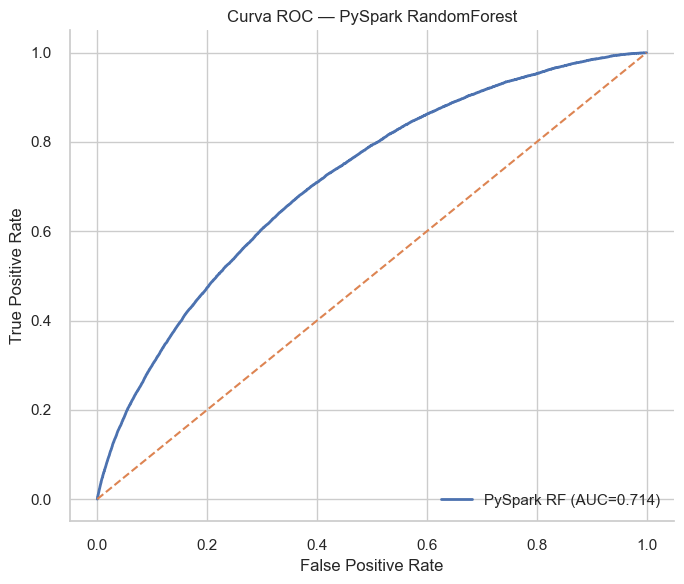

In [ ]:
# Curva ROC 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array

# Extraemos la prob1 
preds_scores = (
    preds_best
    .select(
        col("default").cast("int").alias("label"),
        vector_to_array("probability").getItem(1).alias("prob1")
    )
    .na.drop(subset=["label", "prob1"])
)

ROC_SAMPLE = 100_000
counts_rows = preds_scores.groupBy("label").count().collect()
counts = {int(r["label"]): int(r["count"]) for r in counts_rows}  
n_total = sum(counts.values())
frac_global = min(1.0, ROC_SAMPLE / max(1, n_total))

# Fracción por clase 
fractions = {lbl: min(1.0, frac_global) for lbl in counts.keys()}
preds_sample = preds_scores.sampleBy("label", fractions=fractions, seed=GLOBAL_SEED)

# Traer la muestra al driver
pdf = preds_sample.toPandas()
y_true = pdf["label"].to_numpy(dtype=int)
y_score = pdf["prob1"].to_numpy(dtype=float)

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"PySpark RF (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — PySpark RandomForest")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()




In [50]:
def _safe_stop_spark(_spark):
    try: _spark.stop()
    except Exception: pass

try:
    train_cv.unpersist(blocking=False)
    train_sp.unpersist(blocking=False)
    test_sp.unpersist(blocking=False)
except Exception:
    pass

_safe_stop_spark(spark)
print("Spark detenido.")


Spark detenido.


In [ ]:
from sklearn.ensemble import RandomForestClassifier as SKRF

RESULTS_DIR = RESULTS_DIR if 'RESULTS_DIR' in globals() else "resultados"

best_rf_skl = None
if 'best_rf_skl' in globals() and isinstance(best_rf_skl, SKRF):
    pass

elif 'best_rf' in globals() and isinstance(best_rf, SKRF):
    best_rf_skl = best_rf

# best_estimator_
elif 'gs' in globals() and hasattr(gs, 'best_estimator_') and isinstance(gs.best_estimator_, SKRF):
    best_rf_skl = gs.best_estimator_

# cargado desde disco el modelo sklearn guardado
else:
    import joblib
    model_path = os.path.join(RESULTS_DIR, "modelo_sklearn_rf.pkl")
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"No encuentro {model_path}. "
            "Si no lo has guardado aún, vuelve a la sección de sklearn y guarda el modelo con joblib.dump."
        )
    best_rf_skl = joblib.load(model_path)

# Sanity check
assert isinstance(best_rf_skl, SKRF), "No se pudo recuperar un RandomForestClassifier de scikit-learn como best_rf_skl."
print("Modelo sklearn listo: best_rf_skl")


✅ Modelo sklearn listo: best_rf_skl


In [ ]:
# LIME (sklearn)

import os, numpy as np

RESULTS_DIR = RESULTS_DIR if 'RESULTS_DIR' in globals() else "resultados"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1) Verificar que tenemos el modelo sklearn guardado como alias estable
from sklearn.ensemble import RandomForestClassifier as SKRF
if 'best_rf_skl' not in globals() or not isinstance(best_rf_skl, SKRF):
    raise RuntimeError(
        "No encuentro el modelo sklearn como 'best_rf_skl'. "
        "Asegúrate de crear el alias al final de la sección sklearn:\n"
        "    best_rf_skl = best_rf"
    )

# Verificar LIME
try:
    import lime, lime.lime_tabular
    print("lime versión:", getattr(lime, "__version__", "unknown"))
except Exception as e:
    raise RuntimeError("LIME no está instalado correctamente. Instala con: pip install lime") from e

if 'y_pred' not in globals() or 'y_pred_proba' not in globals():
    y_pred = best_rf_skl.predict(X_test_processed)
    y_pred_proba = best_rf_skl.predict_proba(X_test_processed)[:, 1]

mis_idx = np.where(y_test.values != y_pred)[0]
if mis_idx.size == 0:
    print("No hay mal clasificados; se tomarán 2 instancias aleatorias del test.")
    rng = np.random.default_rng(42)
    mis_idx = rng.choice(np.arange(len(y_test)), size=min(2, len(y_test)), replace=False)
else:
    mis_idx = mis_idx[:2]

from scipy.sparse import csr_matrix

X_train_for_lime = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_for_lime,
    feature_names=feature_names,
    class_names=["No Default", "Default"],
    discretize_continuous=True,
    mode="classification",
    verbose=False,
    random_state=42
)

def _predict_proba_fn(xs):
    xs = np.asarray(xs)
    if hasattr(X_train_processed, "toarray"):
        return best_rf_skl.predict_proba(csr_matrix(xs))
    else:
        return best_rf_skl.predict_proba(xs)

for i, idx in enumerate(mis_idx, start=1):
    x0 = X_test_processed[idx]
    x0_arr = x0.toarray()[0] if hasattr(x0, "toarray") else x0
    exp = explainer.explain_instance(
        x0_arr,
        _predict_proba_fn,
        num_features=10
    )
    html_path = os.path.join(RESULTS_DIR, f"lime_explicacion_{i}.html")
    exp.save_to_file(html_path)
    print(f"[OK] LIME guardado: {html_path}")


lime versión: unknown
[OK] LIME guardado: resultados\lime_explicacion_1.html
[OK] LIME guardado: resultados\lime_explicacion_2.html


,Métrica,scikit-learn,PySpark
0,Accuracy,0.619727,0.643810
1,Precision,0.303478,0.772754
2,Recall,0.698708,0.643810
3,F1-Score,0.423160,0.678927
4,ROC AUC,0.708474,0.712687
5,Train Time (s),505.159685,2472.367182
6,Pred Time (s),1.589581,0.387869


[OK] Guardado comparativo en: resultados\comparacion_metricas.csv


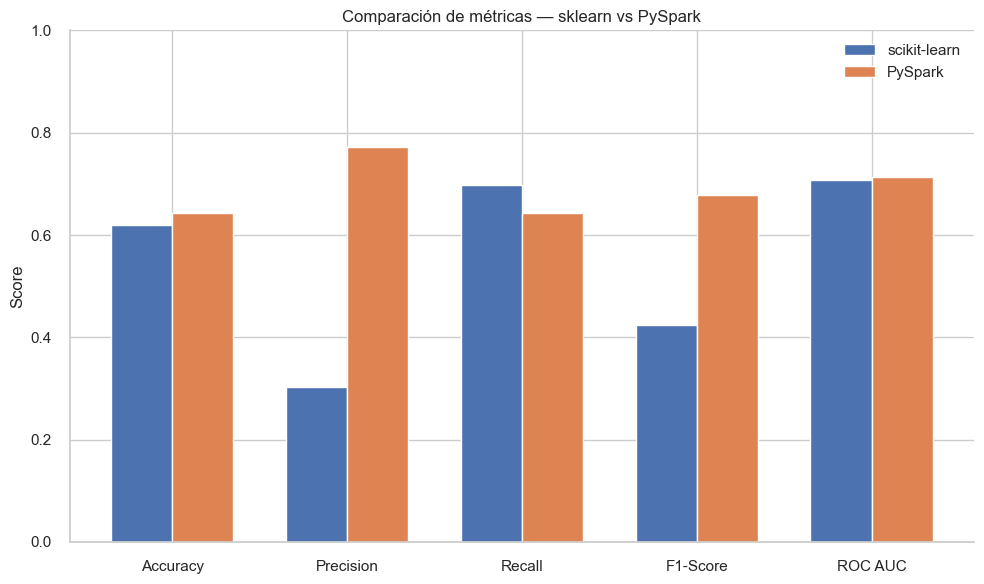

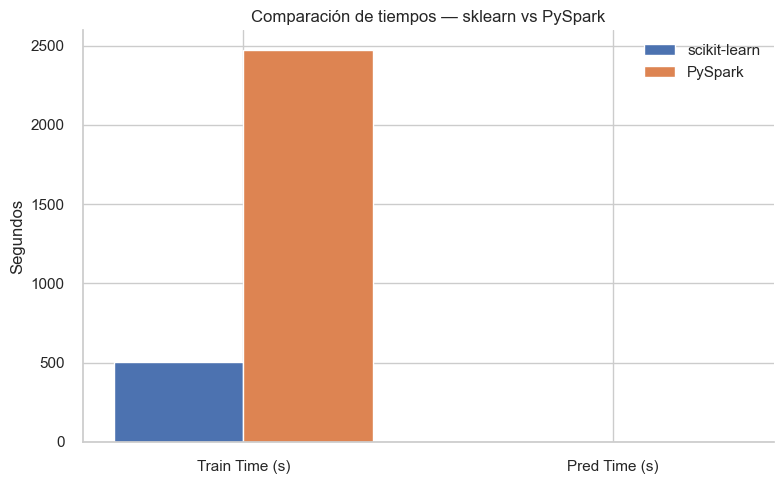

[INFO] Verifica carpeta 'resultados/' para: comparacion_metricas.csv, importancias_sklearn_rf.csv, lime_explicacion_*.html, modelo_sklearn_rf.pkl, scaler.pkl, ohe.pkl (si aplica), imputer(s), clip_bounds.pkl.


In [ ]:
# COMPARACIÓN FINAL + GRÁFICOS + EXPORTABLES

RESULTS_DIR = RESULTS_DIR if 'RESULTS_DIR' in globals() else "resultados"
os.makedirs(RESULTS_DIR, exist_ok=True)

if 'sk_metrics' not in globals():
    raise RuntimeError("Falta 'sk_metrics'. Vuelve a ejecutar la sección de scikit-learn.")
if 'pyspark_metrics' not in globals() or pyspark_metrics is None:
    print("[Aviso] 'pyspark_metrics' no está disponible. La comparación mostrará 'N/A' para Spark.")

# Tabla 
rows = [
    ["Accuracy", sk_metrics.get("Accuracy"), pyspark_metrics.get("Accuracy") if pyspark_metrics else np.nan],
    ["Precision", sk_metrics.get("Precision"), pyspark_metrics.get("Precision") if pyspark_metrics else np.nan],
    ["Recall", sk_metrics.get("Recall"), pyspark_metrics.get("Recall") if pyspark_metrics else np.nan],
    ["F1-Score", sk_metrics.get("F1-Score"), pyspark_metrics.get("F1-Score") if pyspark_metrics else np.nan],
    ["ROC AUC", sk_metrics.get("ROC AUC"), pyspark_metrics.get("ROC AUC") if pyspark_metrics else np.nan],
    ["Train Time (s)", sk_metrics.get("Train Time (s)"), pyspark_metrics.get("Train Time (s)") if pyspark_metrics else np.nan],
    ["Pred Time (s)", sk_metrics.get("Pred Time (s)"), pyspark_metrics.get("Pred Time (s)") if pyspark_metrics else np.nan],
]
comp_df = pd.DataFrame(rows, columns=["Métrica", "scikit-learn", "PySpark"])
display(comp_df)

comp_csv = os.path.join(RESULTS_DIR, "comparacion_metricas.csv")
comp_df.to_csv(comp_csv, index=False)
print(f"[OK] Guardado comparativo en: {comp_csv}")

# Gráfico de barras con métricas 
metrics_bar = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
skl_vals = [sk_metrics[m] for m in metrics_bar]
sp_vals  = [pyspark_metrics[m] if pyspark_metrics else np.nan for m in metrics_bar]

x = np.arange(len(metrics_bar))
w = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - w/2, skl_vals, width=w, label="scikit-learn")
plt.bar(x + w/2, sp_vals,  width=w, label="PySpark")
plt.xticks(x, metrics_bar)
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Comparación de métricas — sklearn vs PySpark")
plt.legend()
plt.tight_layout()
plt.show()

# Gráfico de tiempos
time_bar = ["Train Time (s)", "Pred Time (s)"]
skl_t = [sk_metrics[time_bar[0]], sk_metrics[time_bar[1]]]
sp_t  = [pyspark_metrics[time_bar[0]] if pyspark_metrics else np.nan,
         pyspark_metrics[time_bar[1]] if pyspark_metrics else np.nan]

x = np.arange(len(time_bar))
plt.figure(figsize=(8,5))
plt.bar(x - w/2, skl_t, width=w, label="scikit-learn")
plt.bar(x + w/2, sp_t,  width=w, label="PySpark")
plt.xticks(x, time_bar)
plt.ylabel("Segundos")
plt.title("Comparación de tiempos — sklearn vs PySpark")
plt.legend()
plt.tight_layout()
plt.show()
print("[INFO] Verifica carpeta 'resultados/' para: comparacion_metricas.csv, importancias_sklearn_rf.csv, lime_explicacion_*.html, modelo_sklearn_rf.pkl, scaler.pkl, ohe.pkl (si aplica), imputer(s), clip_bounds.pkl.")


In [ ]:
import sys, platform, os, json
import numpy as np, pandas as pd
import sklearn
try:
    import lime
    lime_version = getattr(lime, "__version__", "unknown")
except Exception:
    lime_version = "unknown"

info = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "lime": lime_version,
    "GLOBAL_SEED": GLOBAL_SEED if 'GLOBAL_SEED' in globals() else None,
    "SPARK_VERSION": spark.version if 'spark' in globals() else None,
    "JAVA_HOME": os.environ.get("JAVA_HOME", None)
}
print(json.dumps(info, indent=2))

env_path = os.path.join(RESULTS_DIR, "environment_summary.json")
with open(env_path, "w", encoding="utf-8") as f:
    json.dump(info, f, indent=2)
print(f"[OK] environment_summary.json guardado en: {env_path}")


{
  "python_version": "3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]",
  "platform": "Windows-10-10.0.26100-SP0",
  "numpy": "1.23.5",
  "pandas": "2.3.1",
  "sklearn": "1.6.1",
  "lime": "unknown",
  "GLOBAL_SEED": 42,
  "SPARK_VERSION": "4.0.1",
  "JAVA_HOME": "C:\\Program Files\\Java\\jdk-21"
}
[OK] environment_summary.json guardado en: resultados\environment_summary.json
